#  AI-Driven Screening for Carbon Capture Materials
### Predicting CO₂ Uptake in Metal-Organic Frameworks (MOFs)

**Goal:** Build a machine learning model that predicts CO₂ uptake capacity  
of a MOF purely from its geometric structure — enabling rapid screening  
of 90,000+ candidates without expensive lab experiments.

---

##  Step 1 — Imports for EDA


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

##  Step 2 — Load Data

In [2]:
df = pd.read_csv("C://Users//admin//OneDrive//Documents//all_MOFs_screening_data.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (324426, 42)
Columns: ['MOFname', 'CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]', 'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]', 'excess_CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2_uptake_P0.10bar_T363K [mmol/g]', 'CO2_uptake_error_P0.10bar_T363K [mmol/g]', 'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]', 'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]', 'excess_CO2_uptake_P0.10bar_T363K [mmol/g]', 'CO2_uptake_P0.70bar_T413K [mmol/g]', 'CO2_uptake_error_P0.70bar_T413K [mmol/g]', 'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]', 'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]', 'excess_CO2_uptake_P0.70bar_T413K [mmol/g]', 'working_capacity_vacuum_swing [mmol/g]', 'working_capacity_temperature_swing [mmol/g]', 'CO2_binary_uptake_P0.15bar_T298K [mmol/g]', 'CO2_binary_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]', 'heat_adsorption_error_CO

##  Step 3 — Basic Inspection
Check data types and first few rows to understand what each column represents.

In [3]:
df.head()

,MOFname,CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_error_P0.15bar_T298K [mmol/g],heat_adsorption_CO2_P0.15bar_T298K [kcal/mol],heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol],excess_CO2_uptake_P0.15bar_T298K [mmol/g],CO2_uptake_P0.10bar_T363K [mmol/g],CO2_uptake_error_P0.10bar_T363K [mmol/g],heat_adsorption_CO2_P0.10bar_T363K [kcal/mol],heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol],...,void_fraction,void_volume [cm^3/g],largest_free_sphere_diameter [A],largest_included_sphere_along_free_sphere_path_diameter [A],largest_included_sphere_diameter [A],functional_groups,metal_linker,organic_linker1,organic_linker2,topology
0,str_m5_o16_o16_sra_sym.77,5.955197,0.117622,9.223227,0.546586,5.955127,0.840043,0.295803,7.972884,5.106942,...,0.14835,0.1480,4.61370,3.78047,4.61370,Pr,9,16,16,sra
1,str_m5_o16_o16_sra_sym.37,5.715251,0.034598,8.391884,0.149962,5.715251,0.901656,0.283054,8.343676,4.785696,...,0.16099,0.1624,4.10210,3.39756,4.10055,OMe,9,16,16,sra
2,str_m5_o13_o18_sra_sym.149,5.524486,0.155094,8.674098,0.753841,5.524486,0.688965,0.191963,7.546794,3.803472,...,0.17980,0.1810,4.24711,3.26179,4.24603,NO2,9,13,18,sra
3,str_m5_o2_o18_sra_sym.4,5.517258,0.084320,10.791553,0.514052,5.517258,1.881691,0.166854,9.246778,1.511943,...,0.10245,0.0922,4.11419,2.93595,3.63925,H,9,2,18,sra
4,str_m5_o16_o16_sra_sym.31,5.451593,0.051989,8.711414,0.260774,5.451476,0.797098,0.254966,8.247735,4.814885,...,0.15634,0.1583,4.37077,3.49681,4.16451,Et,9,16,16,sra


In [4]:
df.dtypes

MOFname                                                         object
CO2_uptake_P0.15bar_T298K [mmol/g]                             float64
CO2_uptake_error_P0.15bar_T298K [mmol/g]                       float64
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                  float64
heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]            float64
excess_CO2_uptake_P0.15bar_T298K [mmol/g]                      float64
CO2_uptake_P0.10bar_T363K [mmol/g]                             float64
CO2_uptake_error_P0.10bar_T363K [mmol/g]                       float64
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                  float64
heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]            float64
excess_CO2_uptake_P0.10bar_T363K [mmol/g]                      float64
CO2_uptake_P0.70bar_T413K [mmol/g]                             float64
CO2_uptake_error_P0.70bar_T413K [mmol/g]                       float64
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                  float64
heat_a

##  Step 4 — Missing Values
Identify which columns have nulls and what percentage of data is affected.  


In [5]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': pct
})

print(missing_df[missing_df['missing_count'] > 0])

                                                    missing_count  missing_pct
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                2087         0.64
heat_adsorption_error_CO2_P0.15bar_T298K [kcal/...           2087         0.64
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                2094         0.65
heat_adsorption_error_CO2_P0.10bar_T363K [kcal/...           2094         0.65
CO2_uptake_P0.70bar_T413K [mmol/g]                            167         0.05
CO2_uptake_error_P0.70bar_T413K [mmol/g]                      167         0.05
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                2100         0.65
heat_adsorption_error_CO2_P0.70bar_T413K [kcal/...           2100         0.65
excess_CO2_uptake_P0.70bar_T413K [mmol/g]                     167         0.05
heat_adsorption_CO2_binary_P0.15bar_T298K [kcal...           2477         0.76
heat_adsorption_error_CO2_binary_P0.15bar_T298K...           2477         0.76
heat_adsorption_N2_binary_P0.85bar_T298K [kcal/...  

##  Step 5 — Target Variable Distribution
Our target is `CO2_uptake_P0.15bar_T298K` — CO₂ uptake at standard  
flue gas conditions (0.15 bar, 298 K).  
We check if it's skewed — skewed targets are harder to predict and  
may need a log transform later.

C:\Users\admin\AppData\Local\Temp\ipykernel_26144\2701082543.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


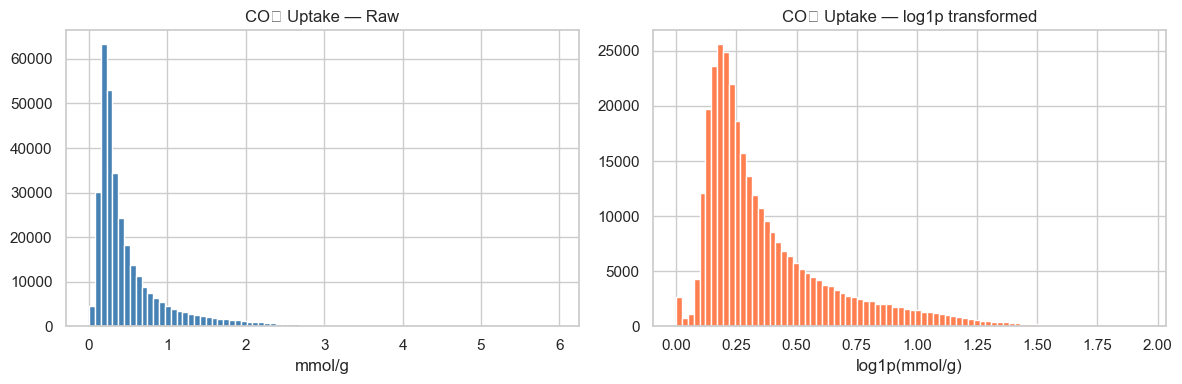

count    324426.000000
mean          0.517388
std           0.532612
min           0.000000
25%           0.204142
50%           0.319067
75%           0.605401
max           5.955197
Name: CO2_uptake_P0.15bar_T298K [mmol/g], dtype: float64


In [6]:
TARGET = 'CO2_uptake_P0.15bar_T298K [mmol/g]'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[TARGET].hist(bins=80, color='steelblue', edgecolor='white')
plt.title('CO₂ Uptake — Raw')
plt.xlabel('mmol/g')

plt.subplot(1, 2, 2)
np.log1p(df[TARGET]).hist(bins=80, color='coral', edgecolor='white')
plt.title('CO₂ Uptake — log1p transformed')
plt.xlabel('log1p(mmol/g)')

plt.tight_layout()
plt.show()

print(df[TARGET].describe())

##  Step 6 — Geometric Feature Distributions
These are the structural descriptors we will use as model inputs.  


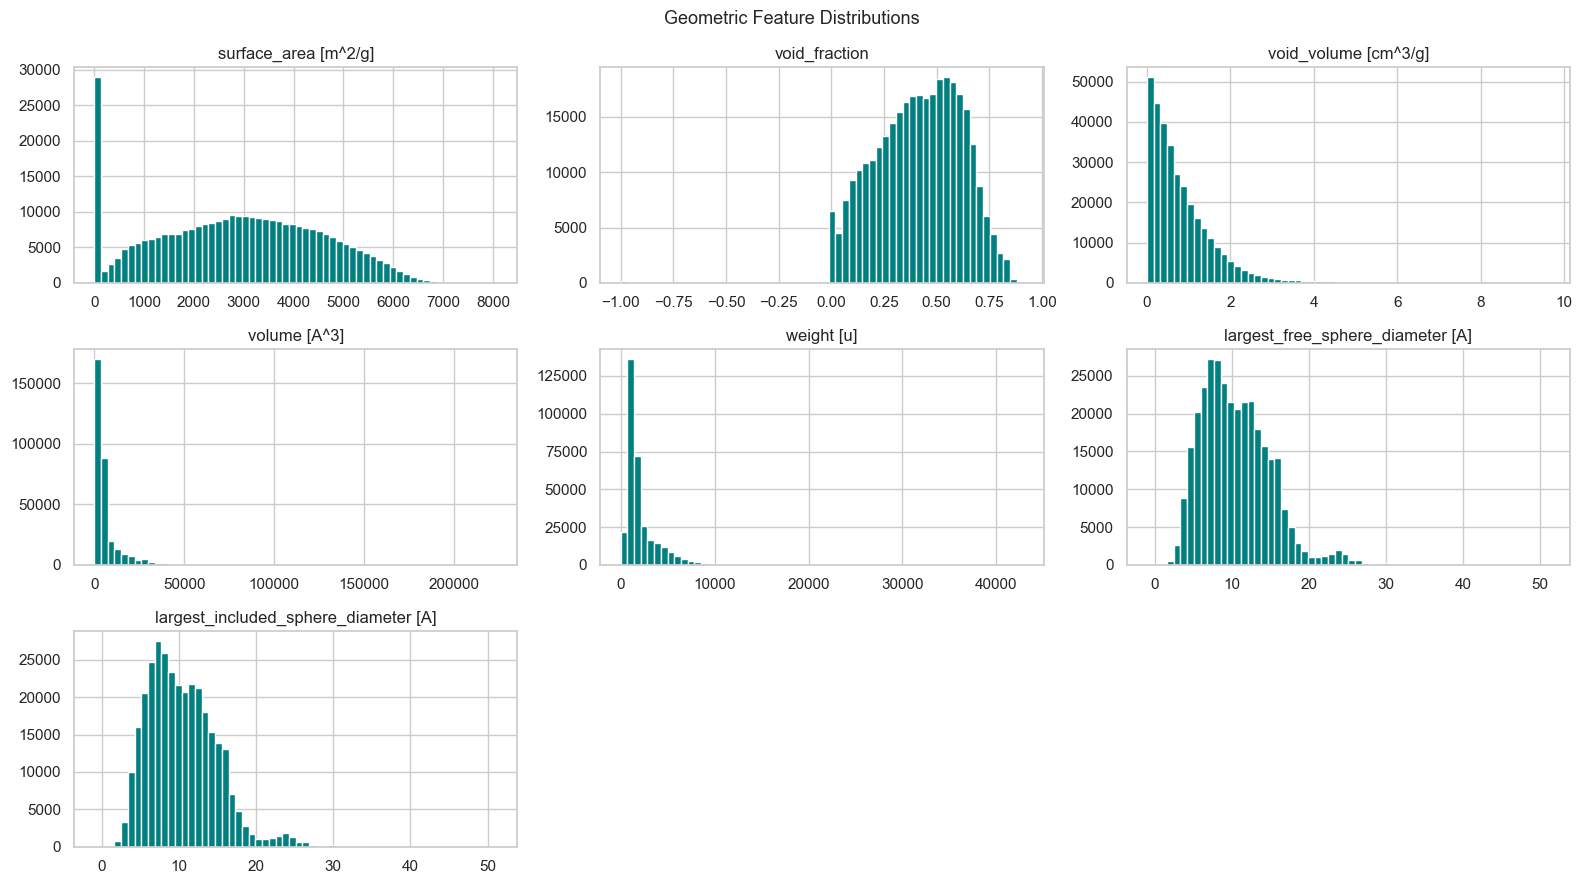

In [7]:
geo_cols = [
    'surface_area [m^2/g]', 'void_fraction',
    'void_volume [cm^3/g]', 'volume [A^3]', 'weight [u]',
    'largest_free_sphere_diameter [A]',
    'largest_included_sphere_diameter [A]'
]

df[geo_cols].hist(bins=60, figsize=(16, 9), color='teal', edgecolor='white')
plt.suptitle('Geometric Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

##  Step 7 — Correlation Heatmap
Shows how strongly each geometric feature correlates with CO₂ uptake.Values close to +1 or -1 = strong relationship with target.  




C:\Users\admin\AppData\Local\Temp\ipykernel_26144\170741506.py:11: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


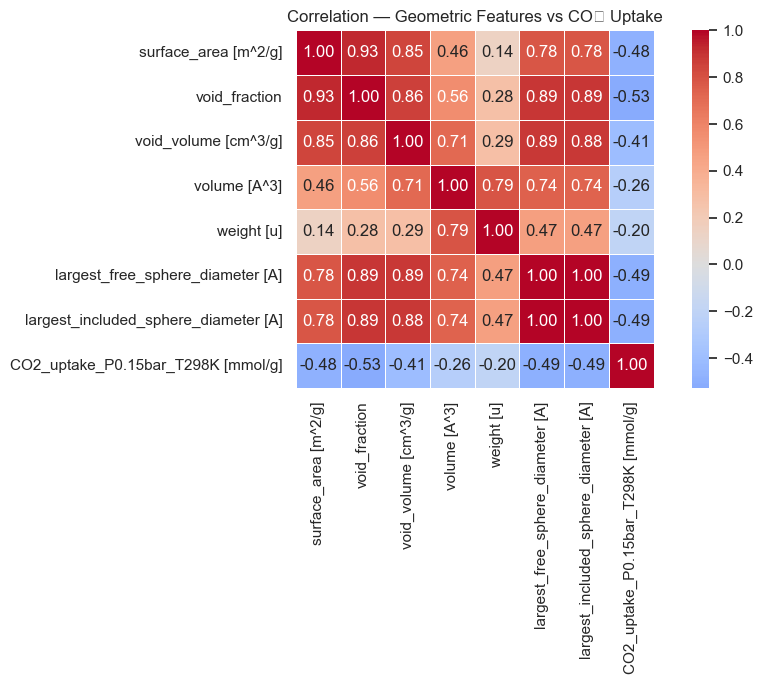

In [8]:
corr_cols = geo_cols + [TARGET]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation — Geometric Features vs CO₂ Uptake')
plt.tight_layout()
plt.show()


##  Step 8 — Categorical Columns Overview
Check how many unique values each categorical column has —  
this decides which encoding strategy we use later.

In [9]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"{col:30s} → {df[col].nunique()} unique values")

MOFname                        → 324426 unique values
functional_groups              → 400 unique values
topology                       → 11 unique values


##  Step 9 — Data Cleaning

In [10]:
# Drop Error / Uncertainty Columns

error_cols = [c for c in df.columns if 'error' in c.lower()]
print("Dropping:", error_cols)
df = df.drop(columns=error_cols)
print("\nShape after dropping error cols:", df.shape)

Dropping: ['CO2_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]', 'CO2_uptake_error_P0.10bar_T363K [mmol/g]', 'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]', 'CO2_uptake_error_P0.70bar_T413K [mmol/g]', 'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]', 'CO2_binary_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_binary_P0.15bar_T298K [kcal/mol]', 'N2_binary_uptake_error_P0.85bar_T298K [mmol/g]', 'heat_adsorption_error_N2_binary_P0.85bar_T298K [kcal/mol]']

Shape after dropping error cols: (324426, 32)


In [11]:
todrop = [
    'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]',
    'excess_CO2_uptake_P0.15bar_T298K [mmol/g]',
    'CO2_uptake_P0.10bar_T363K [mmol/g]',
    'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]',
    'excess_CO2_uptake_P0.10bar_T363K [mmol/g]',
    'CO2_uptake_P0.70bar_T413K [mmol/g]',
    'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]',
    'excess_CO2_uptake_P0.70bar_T413K [mmol/g]',
    #'working_capacity_vacuum_swing [mmol/g]',
    #'working_capacity_temperature_swing [mmol/g]',
    'CO2_binary_uptake_P0.15bar_T298K [mmol/g]',
    'heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]',
    'excess_CO2_binary_uptake_P0.15bar_T298K [mmol/g]',
    'N2_binary_uptake_P0.85bar_T298K [mmol/g]',
    'heat_adsorption_N2_binary_P0.85bar_T298K [kcal/mol]',
    'excess_N2_binary_uptake_P0.85bar_T298K [mmol/g]',
    #'CO2/N2_selectivity',
]
df = df.drop(columns=['MOFname'])
df = df.drop(columns=todrop)
df.shape

(324426, 17)

In [12]:
#Handle Missing Values
df.dropna(inplace=True)


In [13]:
print("Final shape:", df.shape)
print("Null values remaining:", df.isnull().sum().sum())
print("\nRemaining columns:")
print(df.columns.tolist())

Final shape: (322429, 17)
Null values remaining: 0

Remaining columns:
['CO2_uptake_P0.15bar_T298K [mmol/g]', 'working_capacity_vacuum_swing [mmol/g]', 'working_capacity_temperature_swing [mmol/g]', 'CO2/N2_selectivity', 'volume [A^3]', 'weight [u]', 'surface_area [m^2/g]', 'void_fraction', 'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]', 'largest_included_sphere_along_free_sphere_path_diameter [A]', 'largest_included_sphere_diameter [A]', 'functional_groups', 'metal_linker', 'organic_linker1', 'organic_linker2', 'topology']


##  Step 10 — Encoding Categorical Columns
Machine learning models only understand numbers.
We have 3 categorical columns, each needing a different strategy:

| Column | Unique Values | Strategy |
|---|---|---|
| `functional_groups` | ~400 | Frequency Encoding |
| `topology` | 11 | One-Hot Encoding |
| `metal_linker` | 7 | One-Hot Encoding |
| `organic_linker1/2` | 58 | Already integers  |

In [14]:
# Frequency encoding for functional_groups column
"""
freq_map = df['functional_groups'].value_counts()
df['functional_groups'] = df['functional_groups'].map(freq_map)

print(df['functional_groups'].describe())"""

"\nfreq_map = df['functional_groups'].value_counts()\ndf['functional_groups'] = df['functional_groups'].map(freq_map)\n\nprint(df['functional_groups'].describe())"

In [15]:
df = pd.get_dummies(df, columns=['topology', 'metal_linker'], drop_first=False)
df.head()

,CO2_uptake_P0.15bar_T298K [mmol/g],working_capacity_vacuum_swing [mmol/g],working_capacity_temperature_swing [mmol/g],CO2/N2_selectivity,volume [A^3],weight [u],surface_area [m^2/g],void_fraction,void_volume [cm^3/g],largest_free_sphere_diameter [A],...,topology_sra,topology_tbo,topology_the,metal_linker_1,metal_linker_2,metal_linker_3,metal_linker_4,metal_linker_9,metal_linker_10,metal_linker_12
0,5.955197,5.115154,4.458911,109.786792,2473.186302,1493.01184,613.30,0.14835,0.1480,4.61370,...,True,False,False,False,False,False,False,True,False,False
1,5.715251,4.813595,4.404382,126.719639,2419.885159,1444.79680,0.00,0.16099,0.1624,4.10210,...,True,False,False,False,False,False,False,True,False,False
2,5.524486,4.835521,4.313571,141.713366,2514.627698,1504.68312,0.00,0.17980,0.1810,4.24711,...,True,False,False,False,False,False,False,True,False,False
3,5.517258,3.635567,3.221749,274.702092,2128.612920,1424.81024,0.00,0.10245,0.0922,4.11419,...,True,False,False,False,False,False,False,True,False,False
4,5.451593,4.654495,3.824486,101.853896,2415.251225,1436.90552,1347.04,0.15634,0.1583,4.37077,...,True,False,False,False,False,False,False,True,False,False


In [16]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [17]:
df.dtypes

CO2_uptake_P0.15bar_T298K [mmol/g]                             float64
working_capacity_vacuum_swing [mmol/g]                         float64
working_capacity_temperature_swing [mmol/g]                    float64
CO2/N2_selectivity                                             float64
volume [A^3]                                                   float64
weight [u]                                                     float64
surface_area [m^2/g]                                           float64
void_fraction                                                  float64
void_volume [cm^3/g]                                           float64
largest_free_sphere_diameter [A]                               float64
largest_included_sphere_along_free_sphere_path_diameter [A]    float64
largest_included_sphere_diameter [A]                           float64
functional_groups                                               object
organic_linker1                                                  int64
organi

##  Step 11 — Feature Engineering
We create new features from existing geometric columns.  


In [18]:
# Surface area packed per unit volume
df['sa_per_volume'] = df['surface_area [m^2/g]'] / (df['volume [A^3]'] + 1e-9)

# How dense the pores are relative to pore size
df['pore_density'] = df['void_fraction'] / (df['largest_included_sphere_diameter [A]'] + 1e-9)

# Combined adsorption capacity proxy
df['void_x_sa'] = df['void_volume [cm^3/g]'] * df['surface_area [m^2/g]']

print("New shape:", df.shape)

New shape: (322429, 36)


##  Step 12 — Define X and y
Separate the dataset into:
- **x** — all input features (geometry + encoded categoricals)
- **y** — target variable (CO₂ uptake)

### Why log1p transform on y?
The target is right-skewed — most MOFs have low uptake but  
a few have very high values. 
It helped us to increase the r2 score.

In [19]:
TARGET = 'CO2_uptake_P0.15bar_T298K [mmol/g]'

x = df.drop(columns=[TARGET])
y = df[TARGET]

# Log transform target
y_log = np.log1p(y)


##  Step 13 — Train / Validation / Test Split (70 / 15 / 15)

Three separate sets:
- **Train (70%)** — model learns from this
- **Validation (15%)** — monitors overfitting during training via early stopping
- **Test (15%)** — completely untouched until final evaluation


In [20]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y_log, test_size=0.30, random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42
)

In [21]:
# Step 2 fix: Frequency encode functional_groups using ONLY train data
freq_map = x_train['functional_groups'].value_counts()
x_train['functional_groups'] = x_train['functional_groups'].map(freq_map)
x_val['functional_groups']   = x_val['functional_groups'].map(freq_map).fillna(0)
x_test['functional_groups']  = x_test['functional_groups'].map(freq_map).fillna(0)

##  Step 14 — StandardScaler
Transforms each feature to mean=0 and std=1.  


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_sc = pd.DataFrame(scaler.fit_transform(x_train), columns = x_train.columns)
x_test_sc = pd.DataFrame(scaler.transform(x_test), columns = x_test.columns)
x_val_sc = pd.DataFrame(scaler.transform(x_val), columns = x_val.columns)

##  Step 15 — LightGBM Model Training

### Key hyperparameters explained:
| Parameter | Value | Why |
|---|---|---|
| `n_estimators` | 3000 | Max trees — early stopping will find the best point |
| `learning_rate` | 0.02 | Small steps = more careful learning = better generalization |
| `num_leaves` | 255 | Controls tree complexity — higher = more expressive model |
| `subsample` | 0.8 | Each tree uses 80% of rows — reduces overfitting |
| `colsample_bytree` | 0.8 | Each tree uses 80% of features — adds diversity |
| `early_stopping` | 50 rounds | Stops if val loss doesn't improve — prevents overfitting |

In [23]:
!pip install lightgbm

In [24]:
# Fit frequency map only on training data
freq_map = x_train['functional_groups'].value_counts()

x_train['functional_groups'] = x_train['functional_groups'].map(freq_map)
x_val['functional_groups']   = x_val['functional_groups'].map(freq_map).fillna(0)
x_test['functional_groups']  = x_test['functional_groups'].map(freq_map).fillna(0)

### Fix — Clean Column Names for LightGBM
LightGBM does not support special characters in feature names  
like `[ ] ^ / .` — we replace them with underscores.  


In [25]:
import re

# Clean all special characters from column names
x_train_sc.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in x_train_sc.columns]
x_val_sc.columns   = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in x_val_sc.columns]
x_test_sc.columns  = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in x_test_sc.columns]

print("Sample columns after cleaning:")
print(x_train_sc.columns.tolist()[:10])

Sample columns after cleaning:
['working_capacity_vacuum_swing__mmol_g_', 'working_capacity_temperature_swing__mmol_g_', 'CO2_N2_selectivity', 'volume__A_3_', 'weight__u_', 'surface_area__m_2_g_', 'void_fraction', 'void_volume__cm_3_g_', 'largest_free_sphere_diameter__A_', 'largest_included_sphere_along_free_sphere_path_diameter__A_']


In [26]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error

model = lgb.LGBMRegressor(
    n_estimators      = 3000,
    learning_rate     = 0.02,
    num_leaves        = 100,       # reduced from 255
    max_depth         = 10,        # added depth limit
    min_child_samples = 50,        # increased from 10
    subsample         = 0.7,       # reduced from 0.8
    colsample_bytree  = 0.7,       # reduced from 0.8
    reg_alpha         = 0.1,       # increased regularization
    reg_lambda        = 0.1,       # increased regularization
    n_jobs            = -1,
    random_state      = 42
)

model.fit(
    x_train_sc, y_train,
    eval_set  = [(x_val_sc, y_val)],
    callbacks = [
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"Best iteration: {model.best_iteration_}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3930
[LightGBM] [Info] Number of data points in the train set: 225700, number of used features: 34
[LightGBM] [Info] Start training from score 0.373447
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.00183037
[200]	valid_0's l2: 0.000327994
[300]	valid_0's l2: 0.000259066
[400]	valid_0's l2: 0.000237224
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[500]	valid_0's l2: 0.000226321
[600]	valid_0's l2: 0.000219679
[700]	valid_0's l2: 0.000215118
[800]	valid_0's l2: 0.000211608
[900]	valid_0's l2: 0.000208779
[1000]	valid_0's l2: 0.000206278
[1100]	valid_0's l2: 0.000204423
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1200]	valid_0's l2: 0.000202

##  Step 16 — Predictions
We predict on all three sets to check for overfitting.  

Since we trained on `log1p(y)` we must reverse with `expm1()`  
before computing metrics — this gives R² on the original mmol/g scale.

| Transform | Function | Direction |
|---|---|---|
| Compress target | `log1p(y)` | Before training |
| Reverse predictions | `expm1(y_pred)` | After predicting |

In [27]:

y_pred_train = np.expm1(model.predict(x_train_sc))
y_pred_test  = np.expm1(model.predict(x_test_sc))

# Back-transform true labels too
y_train_orig = np.expm1(y_train)
y_test_orig  = np.expm1(y_test)


## Step 17 — Evaluation Metrics
We evaluate using three metrics:
- **R²** — proportion of variance explained (our target is ≥ 0.95)
- **RMSE** — root mean squared error in mmol/g (penalises large errors more)
- **MAE** — mean absolute error in mmol/g (average error size)

Comparing train vs test tells us if the model is overfitting:
- Train R² much higher than val/test → overfitting
- All three close to each other → healthy model

In [28]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Train metrics
r2_train   = r2_score(y_train_orig, y_pred_train)
mse_train  = mean_squared_error(y_train_orig, y_pred_train)
mae_train  = mean_absolute_error(y_train_orig, y_pred_train)

# Test metrics
r2_test    = r2_score(y_test_orig, y_pred_test)
mse_test   = mean_squared_error(y_test_orig, y_pred_test)
mae_test   = mean_absolute_error(y_test_orig, y_pred_test)

print("Train  →  R²:", round(r2_train, 4), " | MSE:", round(mse_train, 4), " | MAE:", round(mae_train, 4))
print("Test   →  R²:", round(r2_test, 4),  " | MSE:", round(mse_test, 4),  " | MAE:", round(mae_test, 4))

Train  →  R²: 0.9979  | MSE: 0.0006  | MAE: 0.0114
Test   →  R²: 0.9947  | MSE: 0.0015  | MAE: 0.0146
